In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('household_power_consumption.csv', 
                  low_memory=False,
                  na_values=['?'])

print(df.columns.tolist())
print(df.head(2))

['Date', 'Time', 'Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']
         Date      Time  Global_active_power  Global_reactive_power  Voltage  \
0  16/12/2006  17:24:00                4.216                  0.418   234.84   
1  16/12/2006  17:25:00                5.360                  0.436   233.63   

   Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3  
0              18.4             0.0             1.0            17.0  
1              23.0             0.0             1.0            16.0  


In [3]:
df = pd.read_csv('household_power_consumption.csv', 
                  low_memory=False,
                  na_values=['?'])

# Combine Date and Time into DateTime
df['DateTime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], dayfirst=True)

# Drop original Date and Time columns
df.drop(columns=['Date', 'Time'], inplace=True)

df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,DateTime
0,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006-12-16 17:24:00
1,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006-12-16 17:25:00
2,5.374,0.498,233.29,23.0,0.0,2.0,17.0,2006-12-16 17:26:00
3,5.388,0.502,233.74,23.0,0.0,1.0,17.0,2006-12-16 17:27:00
4,3.666,0.528,235.68,15.8,0.0,1.0,17.0,2006-12-16 17:28:00


In [4]:
df.tail()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,DateTime
1048570,0.426,0.076,242.27,1.8,0.0,0.0,0.0,2008-12-13 21:34:00
1048571,0.424,0.076,242.10,1.8,0.0,0.0,0.0,2008-12-13 21:35:00
1048572,0.422,0.076,241.73,1.8,0.0,0.0,0.0,2008-12-13 21:36:00
1048573,0.422,0.078,242.56,1.8,0.0,0.0,0.0,2008-12-13 21:37:00
1048574,0.422,0.078,242.61,1.8,0.0,0.0,0.0,2008-12-13 21:38:00


In [5]:
print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())

Shape: (1048575, 8)

Data Types:
 Global_active_power             float64
Global_reactive_power           float64
Voltage                         float64
Global_intensity                float64
Sub_metering_1                  float64
Sub_metering_2                  float64
Sub_metering_3                  float64
DateTime                 datetime64[us]
dtype: object

Missing Values:
 Global_active_power      4069
Global_reactive_power    4069
Voltage                  4069
Global_intensity         4069
Sub_metering_1           4069
Sub_metering_2           4069
Sub_metering_3           4069
DateTime                    0
dtype: int64


In [6]:
df.dropna(inplace=True)
df.set_index('DateTime', inplace=True)
df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
DateTime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


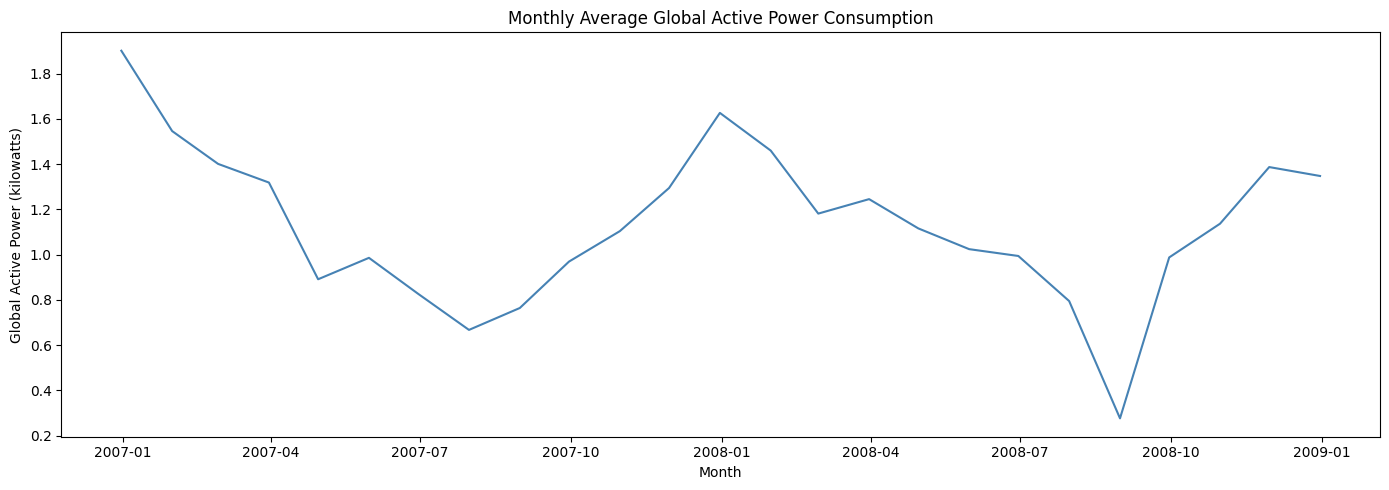

In [7]:
monthly = df['Global_active_power'].resample('ME').mean()
plt.figure(figsize=(14,5))
plt.plot(monthly, color='steelblue')
plt.title('Monthly Average Global Active Power Consumption')
plt.xlabel('Month')
plt.ylabel('Global Active Power (kilowatts)')
plt.tight_layout()
plt.savefig('assets/monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\shaky\AppData\Local\Temp\ipykernel_10708\231712536.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monthly_avg.index, y=monthly_avg.values, palette='coolwarm')


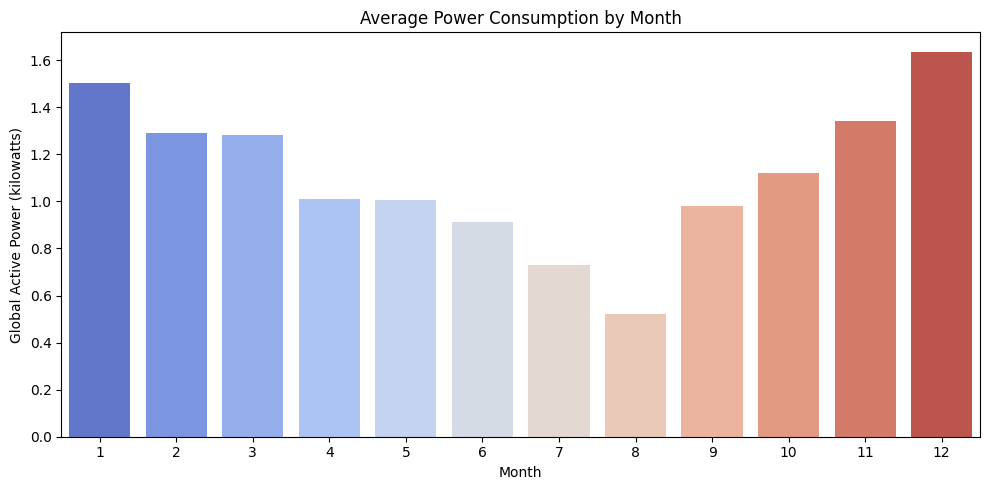

In [8]:
df['Month'] = df.index.month
monthly_avg = df.groupby('Month')['Global_active_power'].mean()

plt.figure(figsize=(10,5))
sns.barplot(x=monthly_avg.index, y=monthly_avg.values, palette='coolwarm')
plt.title('Average Power Consumption by Month')
plt.xlabel('Month')
plt.ylabel('Global Active Power (kilowatts)')
plt.tight_layout()
plt.savefig('assets/seasonal_pattern.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\shaky\AppData\Local\Temp\ipykernel_10708\2970441924.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=hourly_avg.index, y=hourly_avg.values, palette='viridis')


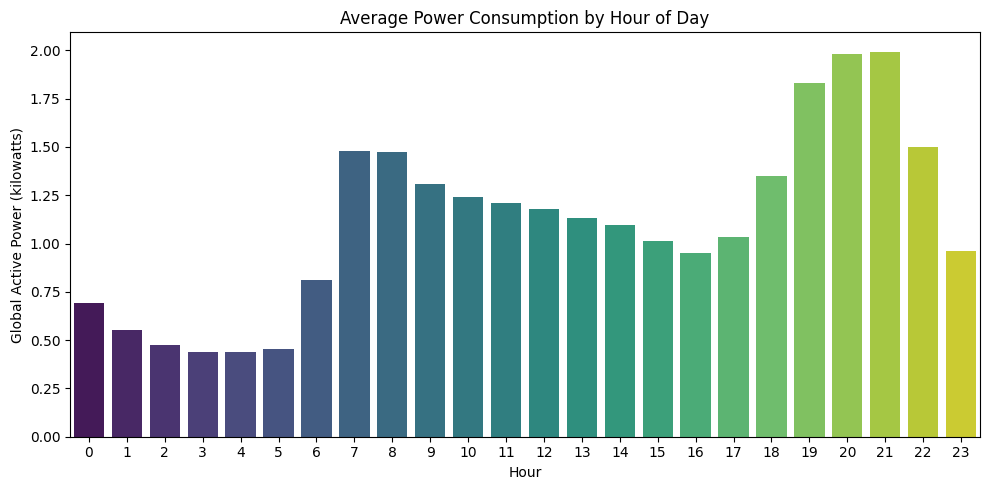

In [9]:
df['Hour'] = df.index.hour
hourly_avg = df.groupby('Hour')['Global_active_power'].mean()

plt.figure(figsize=(10,5))
sns.barplot(x=hourly_avg.index, y=hourly_avg.values, palette='viridis')
plt.title('Average Power Consumption by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Global Active Power (kilowatts)')
plt.tight_layout()
plt.savefig('assets/peak_hours.png', dpi=150, bbox_inches='tight')
plt.show()

Total anomalies detected: 18118


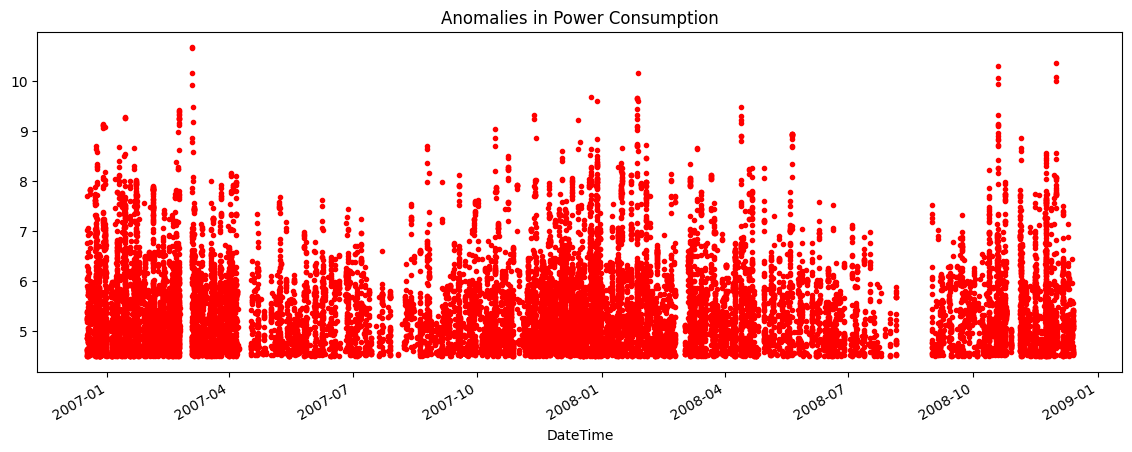

In [10]:
mean = df['Global_active_power'].mean()
std = df['Global_active_power'].std()

anomalies = df[df['Global_active_power'] > mean + 3*std]
print(f"Total anomalies detected: {len(anomalies)}")
anomalies['Global_active_power'].plot(style='.', color='red', figsize=(14,5),
                                       title='Anomalies in Power Consumption')
plt.savefig('assets/anomalies.png', dpi=150, bbox_inches='tight')
plt.show()

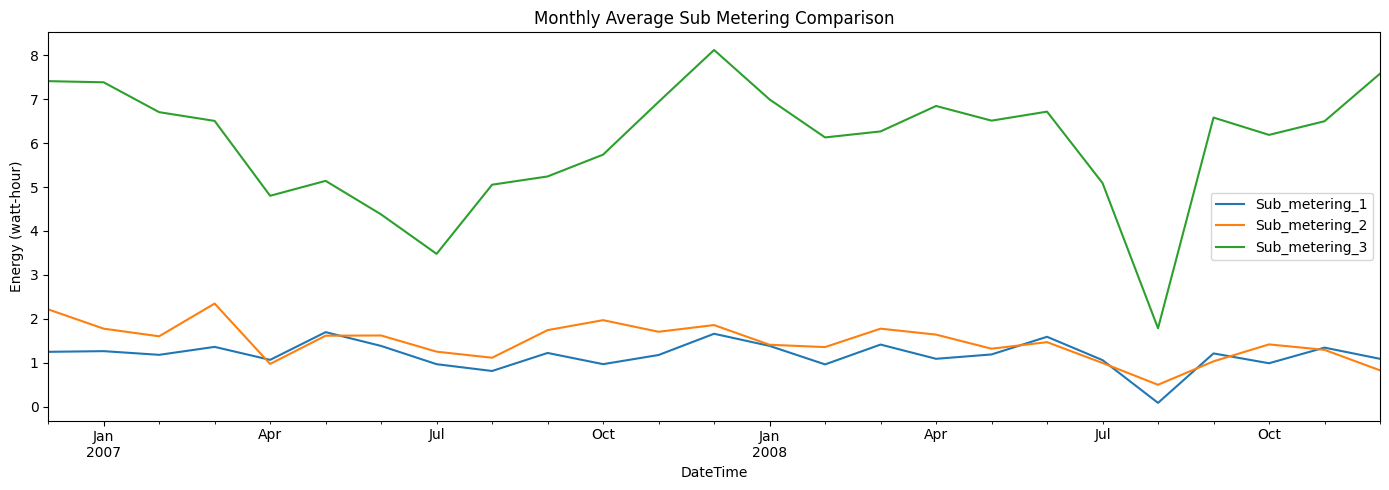

In [11]:
sub = df[['Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']].resample('ME').mean()

sub.plot(figsize=(14,5))
plt.title('Monthly Average Sub Metering Comparison')
plt.ylabel('Energy (watt-hour)')
plt.tight_layout()
plt.savefig('assets/sub_metering.png', dpi=150, bbox_inches='tight')
plt.show()